# Exam

> Data: **2025-02-18**
>
> Autore: **Luigi Malaguti**

##

---

## Parte 0: Il Dataset

Preso e modificato da [Kaggle](https://www.kaggle.com/datasets/yasserh/loan-default-dataset), il dataset è scaricabile attraverso il [link](https://bit.ly/4gFUCwt) e contiene dati relativi ad alcune richieste di prestito. Lo scopo è predire se il prestito è in stato di inadempimento. Sono presenti le seguenti feature:

- `ID`: identificatore del richiedente
- `year`: anno della richiesta di prestito
- `Gender`: sesso del richiedente
- `age`: età del richiedente
- `approv_in_adv`: indica se il prestito è stato approvato in anticipo (pre) oppure no (nopre)
- `loan_type`: tipo di prestito
- `loan_purpose`: scopo del prestito
- `open_credit`: indica se il richiedente ha conti a credito aperti (opc) oppure no (nopc)
- `business_or_commercial`: indica se il prestito ha scopi commerciali (b/c) oppure no (nob/c)
- `loan_amount`: importo del prestito
- `rate_of_interest`: tasso d'interesse applicato al prestito
- `term`: durata del prestito in mesi
- `lump_sum_payment`: indica se alla fine del prestito è richiesto un pagamento forfettario
- `property_value`: valore della proprietà per cui si chiede il prestito
- `construction_type`: tipo di costruzione (sb - sito costruito, mh - fabbricato)
- `occupancy_type`: tipo di occupazione (pr -residenza primaria, sr -res. second., ir -inv. immob.)
- `total_units`: numero di unità del bene oggetto del finanziamento (1U, 2U, 3U, 4U)
- `income`: reddito annuo del richiedente
- `credit_type`: tipo di credito del richiedente
- `Credit_Score`: credit score del richiedente
- `co-applicant_credit_type`: tipo di credito del co-richiedente
- `submission_of_application`: modalità di presentazione della richiesta
- `Region`: regione geografica in cui si trova la proprietà (nord, sud, centro, nord-est)
- `Status`: indica se il prestito è in stato di inadempimento (1) oppure no (0)

### Imports

In [1]:
# !curl -sLo dataset.zip "https://link"
# !unzip -o dataset.zip
# !mv file.csv dataset.csv
FILE_ID = "1MCtgV2tAfv3YdhGqA_Tmk2qi2svQFNfC"
!curl -sLo dataset.csv "https://drive.google.com/uc?export=download&id={FILE_ID}"

In [82]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import ExtraTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD

### Dataset

In [3]:
df = pd.read_csv("dataset.csv")

#### Overview

In [4]:
df.head()

,ID,year,Gender,approv_in_adv,loan_type,loan_purpose,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,occupancy_type,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,Region,Status
0,24890,2019,Sex Not Available,nopre,type1,p1,nopc,nob/c,116500,NaN,...,pr,1U,1740.0,EXP,758.0,CIB,25-34,to_inst,south,0
1,24891,2019,Male,nopre,type2,p1,nopc,b/c,206500,NaN,...,pr,1U,4980.0,EQUI,552.0,EXP,55-64,to_inst,North,1
2,24892,2019,Male,pre,type1,p1,nopc,nob/c,406500,4.56,...,pr,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,south,1
3,24893,2019,Male,nopre,type1,p4,nopc,nob/c,456500,4.25,...,pr,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,North,0
4,24894,2019,Joint,pre,type1,p1,nopc,nob/c,696500,4.00,...,pr,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,North,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21944 entries, 0 to 21943
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         21944 non-null  int64  
 1   year                       21944 non-null  int64  
 2   Gender                     21944 non-null  object 
 3   approv_in_adv              21813 non-null  object 
 4   loan_type                  21944 non-null  object 
 5   loan_purpose               21927 non-null  object 
 6   open_credit                21944 non-null  object 
 7   business_or_commercial     21944 non-null  object 
 8   loan_amount                21944 non-null  int64  
 9   rate_of_interest           16597 non-null  float64
 10  term                       21935 non-null  float64
 11  lump_sum_payment           21944 non-null  object 
 12  property_value             19702 non-null  float64
 13  construction_type          21943 non-null  obj

#### Instances

In [6]:
df.shape

(21944, 24)

#### Missing values

In [7]:
df.isnull().sum().sum()

np.int64(9125)

#### Balancing

In [8]:
df["Status"].value_counts()

,count
Status,
1,11014
0,10930


<Axes: >

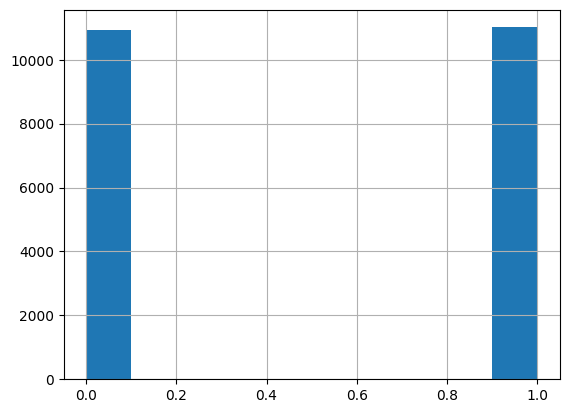

In [9]:
df["Status"].hist()

##

---

## Parte 1: Analisi (Punti 10)

### Domanda 01 (Punti 1)

Quante sono le istanze contenute nel dataset? Il dataset è completo (cioè per ogni istanza tutti i valori di ogni attributo sono sempre correttamente specificati - non esistono "missing values")? Il dataset è bilanciato rispetto alla classe da predire?

In [10]:
df.shape[0]

21944

> Il dataset contiene 21944 istanze.

In [11]:
df.isnull().sum().sum()

np.int64(9125)

> Il datset non risulta completo, in quanto sono presenti 9125 missing values.

In [12]:
df["Status"].value_counts()

,count
Status,
1,11014
0,10930


> Si, il dataset risulta essere abbastanza bilanciato rispetto alla variabile da predire `Status`.

---

### Domanda 02 (Punti 2)

Calcolare nella nuova colonna "ratio" il rapporto tra l’importo del prestito (`loan_amount`) e il valore della proprietà (`property_value`). Calcolare il valore medio di questo rapporto in base al numero di unità della costruzione (`total_units`). Si può affermare che maggiore è il numero di unità, maggiore è il rapporto?

In [13]:
df["ratio"] = df["loan_amount"] / df["property_value"]
df[["loan_amount", "property_value", "ratio", "total_units"]]

,loan_amount,property_value,ratio,total_units
0,116500,118000.0,0.987288,1U
1,206500,NaN,NaN,1U
2,406500,508000.0,0.800197,1U
3,456500,658000.0,0.693769,1U
4,696500,758000.0,0.918865,1U
...,...,...,...,...
21939,146500,198000.0,0.739899,1U
21940,286500,338000.0,0.847633,1U
21941,266500,378000.0,0.705026,1U
21942,586500,NaN,NaN,1U


In [14]:
df.groupby("total_units")["ratio"].mean()

,ratio
total_units,
1U,0.732230
2U,0.612850
3U,0.586999
4U,0.607033


<Axes: xlabel='total_units'>

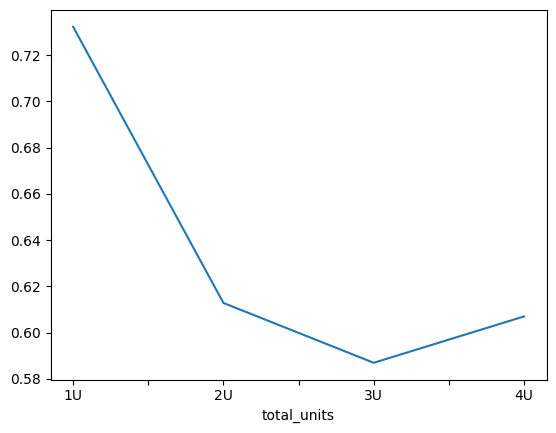

In [15]:
df.groupby("total_units")["ratio"].mean().plot()

> No, all'aumentare del numero di unità, `total_units`, il rapporto `ratio` risulta essere minore rispetto ai `ratio` con meno unità.

---

### Domanda 03 (Punti 3)

Verificare, soltanto per i richiedenti con più di 55 anni, attraverso una tabella pivot se è vero che chi ha un reddito annuo maggiore e un credit score maggiore ha più probabilità di essere in regola con i pagamenti (`status`). Per fare questa analisi discretizzare le feature `income` e `Credit_score` in 5 intervalli.

In [16]:
df["age"].unique()

array(['25-34', '55-64', '35-44', '45-54', '65-74', '>74', '<25', nan],
      dtype=object)

In [17]:
over_55 = df[df["age"].isin(["55-64", "65-74", ">74"])].copy()
over_55["income"] = pd.cut(over_55["income"], bins=5)
over_55["Credit_Score"] = pd.cut(over_55["Credit_Score"], bins=5)

In [18]:
over_55.pivot_table(index="income", columns="Credit_Score", values="Status", aggfunc="mean", observed=False)

Credit_Score,"(499.6, 580.0]","(580.0, 660.0]","(660.0, 740.0]","(740.0, 820.0]","(820.0, 900.0]"
income,,,,,
"(-146.22, 29244.0]",0.493961,0.502497,0.480712,0.518094,0.472716
"(29244.0, 58488.0]",0.555556,0.300000,0.600000,0.375000,0.555556
"(58488.0, 87732.0]",1.000000,NaN,0.500000,0.400000,0.500000
"(116976.0, 146220.0]",NaN,0.000000,NaN,0.000000,NaN


In [19]:
over_55.pivot_table(index="income", columns="Credit_Score", values="Status", aggfunc="count", observed=False)

Credit_Score,"(499.6, 580.0]","(580.0, 660.0]","(660.0, 740.0]","(740.0, 820.0]","(820.0, 900.0]"
income,,,,,
"(-146.22, 29244.0]",1656,1602,1685,1658,1686
"(29244.0, 58488.0]",9,10,5,8,9
"(58488.0, 87732.0]",4,0,2,5,4
"(87732.0, 116976.0]",0,0,0,0,0
"(116976.0, 146220.0]",0,1,0,1,0


> No, dai dati non si potrebbe dire con certezza che maggiore sono il reddito annuo e il credit score, allora si ha più probabilità di essere in regola con i pagamenti. Questo per due motivi, il primo è banalmente che sono presenti dati per cui a redditi bassi o credit score bassi, si ha una probabilità maggiore, mentre il secondo riguarda al bilanciamento dei dati rispetto all'attributo `income`. Infatti, quest'ultimo non è bilanciato per quanto riguarda i 5 bins creati, c'è una netta disuguaglianza tra il primo bin e tutti i restanti.

---

### Domanda 04 (Punti 4)

Si immagina che chi chiede un prestito per una proprietà che è la sua residenza primaria (`occupancy_type`) sia più attento ad essere in regola con i pagamenti. I dati confermano questa considerazione? Visualizzare in un opportuno grafico e soltanto per i prestiti relativi a residenze primarie, la correlazione tra l’importo del prestito e il valore della proprietà. Quali conclusioni si possono trarre?

In [20]:
df.groupby("occupancy_type")["Status"].mean()

,Status
occupancy_type,
ir,0.498612
pr,0.502254
sr,0.495633


> No, non sembrerebbe che i richiedenti di un prestito per la residenza primaria stia più attento ad essere in regola. Infatti le percentuali risultano essere pressoché identiche per ogni tipologia di `occupancy_type`.

<Axes: xlabel='loan_amount', ylabel='property_value'>

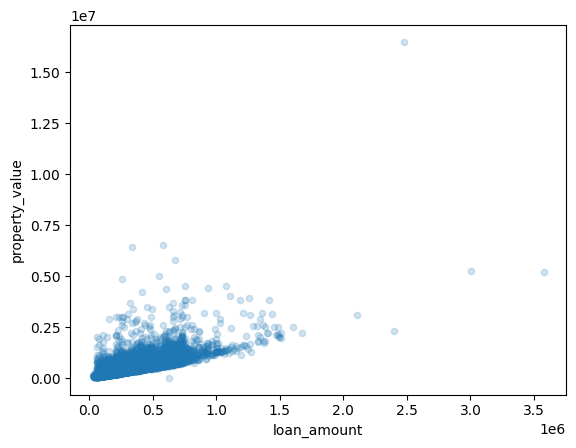

In [21]:
df[df["occupancy_type"] == "pr"].plot(kind="scatter", x="loan_amount", y="property_value", alpha=0.2)

> Dallo scatter plot potremmo dedurre che l'aumento del prestito richiesto non è troppo correlato con l'aumento del valore dell'immobile. Infatti il grafico di estende al di sotto della bisettriche che renderebbe l'aumento lineare delle due variabili, indicandoci come appunto aumenti più il prestito richiesto rispetto all'aumento del valore dell'immobile.

##

---

## Parte 2: Trasformazione e Predizione (Punti 20)

### Domanda 01 (Punti 4)

Si vuole predire se il prestito è in stato di inadempimento oppure no. Ricaricare il dataset originale, eliminare eventuali attributi inutili (giustificare la scelta), eliminare le istanze che contengono valori nulli, trasformare opportunamente i valori categorici e dividere il dataset in train (3/4 del dataset) e test (1/4), preservando le proporzioni delle classi nella colonna target. Confrontare la predizione ottenuta sia sul dataset train sia sul dataset test dai classificatori ExtraTreeClassifier, KNeighborsClassifier e da un dummy classifier a scelta. Effettuare alcune considerazioni sui risultati ottenuti, tenendo in considerazione i valori di F1 e della confusion matrix.

In [22]:
df = pd.read_csv("dataset.csv")
df.drop(["ID", "year"], axis=1, inplace=True)
df.dropna(inplace=True)

one_hot_columns = ["approv_in_adv", "open_credit", "business_or_commercial", "construction_type"]
ordinal_columns = df.drop(one_hot_columns, axis=1).select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=one_hot_columns)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df[ordinal_columns] = ordinal.fit_transform(df[ordinal_columns])

> Sono stati rimossti gli attributi `ID`, `year`. Entrambi gli attributi sono stati rimossi per evitare che i modelli possano trovare pattern di predizione attraverso delle feature che non ne mostrano. `ID` è un semplice identificativo per il record, mentre `year` mostra solo l'anno 2019 in tutto il dataset, quindi non darebbe informazioni utili al fine della predizione.

In [23]:
X, y = df.drop("Status", axis=1), df["Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [24]:
models = {
    "ExtraTree": ExtraTreeClassifier(random_state=0),
    "KNeighbors": KNeighborsClassifier(),
    "Dummy": DummyClassifier(strategy="most_frequent", random_state=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(name)
    print("=" * 30)
    print("TRAIN")
    print("    Accuracy:", accuracy_score(y_train, y_pred_train))
    print("    F1:", f1_score(y_train, y_pred_train))
    print(confusion_matrix(y_train, y_pred_train))
    print("-" * 30)
    print("TEST")
    print("    Accuracy:", accuracy_score(y_test, y_pred_test))
    print("    F1:", f1_score(y_test, y_pred_test))
    print(confusion_matrix(y_test, y_pred_test))
    print("=" * 30)
    print()

ExtraTree
TRAIN
    Accuracy: 1.0
    F1: 1.0
[[5763    0]
 [   0 5736]]
------------------------------
TEST
    Accuracy: 0.4934793948878456
    F1: 0.4934793948878456
[[946 976]
 [966 946]]

KNeighbors
TRAIN
    Accuracy: 0.684755196104009
    F1: 0.683323141434437
[[3963 1800]
 [1825 3911]]
------------------------------
TEST
    Accuracy: 0.4947835159102765
    F1: 0.49332984567093907
[[954 968]
 [969 943]]

Dummy
TRAIN
    Accuracy: 0.5011740151317506
    F1: 0.0
[[5763    0]
 [5736    0]]
------------------------------
TEST
    Accuracy: 0.5013041210224308
    F1: 0.0
[[1922    0]
 [1912    0]]



> I valori di performance ottenuti sono abbastanza scadenti per tutti i modelli. Come prima cosa, possiamo notare che i valori di accuracy e F1 sono quasi identici, questo lo possiamo attribuire al fatto che le confusion matrix abbiano valori tutti molto simili. Infatti, come seconda cosa, possiamo notare che tutti i modelli sbagliano predizioni in modo abbastanza omogeneo, ovvero predicono con le stesse percentuali la classe 0 come classe 1 e viceversa. Questo porta a tutti i modelli ad avere performance del 50% circa.
>
> Altre note possono riguardare al modello `ExtraTree` che sul dataset di train ottiene performance massime, dovuto molto alla natura ad albero del modello stesso, e una seconda nota può riguardare al modello `Dummy`. Questo modello predice sempre la classe maggioritaria, che in questo caso risulta essere bilanciata, quindi produce valori del 50%, ma rimangono predizioni a priori e non veritiere.

---

### Domanda 02 (Punti 1)

Confrontare i valori di F1 del punto precedente con quelli ottenuti con una 10 Fold cross validation.

In [25]:
for name, model in models.items():
    scores = cross_val_predict(model, X, y, cv=10)
    print(name)
    print("=" * 30)
    print("    Score mean:", scores.mean())
    print("    Scores:", scores)
    print("=" * 30)
    print()

ExtraTree
    Score mean: 0.5057066457966477
    Scores: [0 0 0 ... 0 1 0]

KNeighbors
    Score mean: 0.49220635231200677
    Scores: [0 0 0 ... 0 0 1]

Dummy
    Score mean: 0.0
    Scores: [0 0 0 ... 0 0 0]



> Anche attraverso la 10 fold cross validation, le performance dei modelli risultano le medesime, solamente il `ExtraTree` aumenta leggermente di più l'accuratezza, ma rimanendo al 50%.

---

### Domanda 03 (Punti 3)

Calcolare, nelle predizioni ottenute dai modelli dei classificatori ExtraTreeClassifier e KNeighborsClassifier, la probabilità di avere un prestito in stato di inadempimento se si è donna. La probabilità è la stessa per gli uomini? Riportare alcune considerazioni sul confronto dei due modelli.

In [48]:
extra_tree = models["ExtraTree"]
y_pred = extra_tree.predict(X_test)

mask_female = X_test["Gender"] == 0
mask_male = X_test["Gender"] == 2
mask_status_1 = y_pred == 1

probability_status_1_female = y_pred[mask_female & mask_status_1].shape[0] / y_pred[mask_female].shape[0]
probability_status_1_male = y_pred[mask_male & mask_status_1].shape[0] / y_pred[mask_male].shape[0]

print("Probability of status 1 given female:", probability_status_1_female)
print("Probability of status 1 given male:", probability_status_1_male)

ratio = probability_status_1_female / probability_status_1_male if probability_status_1_female < probability_status_1_male else probability_status_1_male / probability_status_1_female
print("Ratio:", ratio)

Probability of status 1 given female: 0.5040106951871658
Probability of status 1 given male: 0.513902205177373
Ratio: 0.9807521550003991


In [49]:
kneighbors = models["KNeighbors"]
y_pred = kneighbors.predict(X_test)

mask_female = X_test["Gender"] == 0
mask_male = X_test["Gender"] == 2
mask_status_1 = y_pred == 1

probability_status_1_female = y_pred[mask_female & mask_status_1].shape[0] / y_pred[mask_female].shape[0]
probability_status_1_male = y_pred[mask_male & mask_status_1].shape[0] / y_pred[mask_male].shape[0]

print("Probability of status 1 given female:", probability_status_1_female)
print("Probability of status 1 given male:", probability_status_1_male)

ratio = probability_status_1_female / probability_status_1_male if probability_status_1_female < probability_status_1_male else probability_status_1_male / probability_status_1_female
print("Ratio:", ratio)

Probability of status 1 given female: 0.4839572192513369
Probability of status 1 given male: 0.5081495685522531
Ratio: 0.9523912824134799


> In entrambi i modelli, la probabilità di avere un prestito in stato di inadempimento risulta essere leggermente più alta per gli uomini, anche se poco più di un punto percentuale. In generale, le probabilità sembrano essere abbastanza simili, sintomo del fatto che i modelli sembrano essere abbastanza equi nelle predizioni.

---

### Domanda 04 (Punti 4)

Analizzare la correlazione tra le feature del dataset, creare un dataframe che contiene, oltre alla colonna target, le 2 feature più correlate positivamente al target e le 2 feature più correlate negativamente al target. La predizione dell'ExtraTreeClassifier migliora?

In [65]:
positive_correlation = df.corr()["Status"].dropna().sort_values(ascending=False)[:3]
negative_correlation = df.corr()["Status"].dropna().sort_values(ascending=False)[-2:]
df_correlation = df[positive_correlation.index.to_list() + negative_correlation.index.to_list()]
df_correlation

,Status,business_or_commercial_b/c,loan_type,business_or_commercial_nob/c,loan_purpose
2,1,False,0,True,0
3,0,False,0,True,3
4,0,False,0,True,0
5,1,False,0,True,0
6,1,False,0,True,2
...,...,...,...,...,...
21935,1,False,0,True,3
21937,1,False,0,True,3
21939,1,False,0,True,2
21940,0,True,1,False,2


In [68]:
X, y = df_correlation.drop("Status", axis=1), df_correlation["Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [69]:
extra_tree.fit(X_train, y_train)
y_pred = extra_tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5075639019300991
F1: 0.35120274914089344
[[1435  487]
 [1401  511]]


> L'accuratezza del modello `ExtraTree` rimane sempre sul 50%, mentre il valore di F1 scende al 35%. Questo perché cambiano le proporzioni dell'errore tra le due classi. Il modello predice prevalentemente la classe 1 come classe 0, molte più volte rispetto al predire la classe 0 come classe 1.

---

### Domanda 05 (Punti 2)

A partire dal dataset utilizzato al punto 1, trovare i valori migliori dei parametri `criterion` e `max_depth` del classificatore ExtraTreeClassifier. Come varia il valore di F1?

In [70]:
df = pd.read_csv("dataset.csv")
df.drop(["ID", "year"], axis=1, inplace=True)
df.dropna(inplace=True)

one_hot_columns = ["approv_in_adv", "open_credit", "business_or_commercial", "construction_type"]
ordinal_columns = df.drop(one_hot_columns, axis=1).select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=one_hot_columns)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df[ordinal_columns] = ordinal.fit_transform(df[ordinal_columns])

In [71]:
X, y = df.drop("Status", axis=1), df["Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [73]:
params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 2, 4, 6, 8, 10],
}
grid_search = GridSearchCV(
    estimator=extra_tree,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'criterion': 'entropy', 'max_depth': 8}
Best score: 0.5058708323089435
Accuracy: 0.5101721439749609
F1: 0.29451540195341847
[[1564  358]
 [1520  392]]


> Come nel punto precedente, l'accuracy sembra aumentare di un punto percentuale, mentre il valore di F1 scende ulteriormente, fino a quasi il 30%. Infatti questo viene mostrato dalla confusion matrix, dove gli errori commessi al punto precedente sono ancora più marcati. Sempre più istanze di classe 1 vengono predette come istanze di classe 0.

---

### Domanda 06 (Punti 3)

Creare una pipeline in cui, a partire dal dataset utilizzato al punto 1, i valori degli attributi `income` e `loan_amount` sono discretizzati in 7 intervalli, `Credit_Score` è scalato con StandardScaler e tutti gli altri attributi sono lasciati invariati. Applicare il modello ExtraTreeClassifier e confrontare i risultati.

In [89]:
df = pd.read_csv("dataset.csv")
df.drop(["ID", "year"], axis=1, inplace=True)
df.dropna(inplace=True)

one_hot_columns = ["approv_in_adv", "open_credit", "business_or_commercial", "construction_type"]
ordinal_columns = df.drop(one_hot_columns, axis=1).select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=one_hot_columns)
ordinal = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=int)
df[ordinal_columns] = ordinal.fit_transform(df[ordinal_columns])

In [90]:
X, y = df.drop("Status", axis=1), df["Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/4, stratify=y, random_state=0)

In [91]:
discretizer = KBinsDiscretizer(n_bins=7, random_state=0)
scaler = StandardScaler()

column_transformer = ColumnTransformer(
    transformers=[
        ("discretizer", discretizer, ["income", "loan_amount"]),
        ("scaler", scaler, ["Credit_Score"]),
    ],
    remainder="passthrough",
    force_int_remainder_cols=False,
)
column_transformer

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  transformers=[('discretizer',
                                 KBinsDiscretizer(n_bins=7, random_state=0),
                                 ['income', 'loan_amount']),
                                ('scaler', StandardScaler(), ['Credit_Score'])])

In [92]:
best_criterion = grid_search.best_params_["criterion"]
best_max_depth = grid_search.best_params_["max_depth"]
extra_tree = ExtraTreeClassifier(criterion=best_criterion, max_depth=best_max_depth, random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("extra_tree", extra_tree),
    ]
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=7,
                                                                   random_state=0),
                                                  ['income', 'loan_amount']),
                                                 ('scaler', StandardScaler(),
                                                  ['Credit_Score'])])),
                ('extra_tree',
                 ExtraTreeClassifier(criterion='entropy', max_depth=8,
                                     random_state=0))])

In [93]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5059989567031821
F1: 0.4154320987654321
[[1267  655]
 [1239  673]]


> L'accuratezza del modello rimane sempre sul 50%, ma questa volta il valore di F1 risulta maggiore rispetto ai precedenti punti. Infatti arriva ad un valore di 41% e mostra meno errori nella predizione della classe 1, passando da ~1500 a ~1200.

---

### Domanda 07 (Punti 3)

Aggiungere alla pipeline precedente la funzione TruncatedSVD per ridurre la dimensionalità del dataset. Valutare i valori migliori di `n_components` di TruncatedSVD e dei parametri `criterion` e `max_depth` di ExtraTreeClassifier, confronta i risultati con i precedenti.

In [94]:
svd = TruncatedSVD(random_state=0)

pipeline = Pipeline(
    steps=[
        ("column_transformer", column_transformer),
        ("svd", svd),
        ("extra_tree", extra_tree),
    ]
)
pipeline

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('discretizer',
                                                  KBinsDiscretizer(n_bins=7,
                                                                   random_state=0),
                                                  ['income', 'loan_amount']),
                                                 ('scaler', StandardScaler(),
                                                  ['Credit_Score'])])),
                ('svd', TruncatedSVD(random_state=0)),
                ('extra_tree',
                 ExtraTreeClassifier(criterion='entropy', max_depth=8,
                                     random_state=0))])

In [96]:
params = {
    "svd__n_components": [2, 4, 8, 16],
    "extra_tree__criterion": ["gini", "entropy", "log_loss"],
    "extra_tree__max_depth": [None, 2, 4, 6, 8, 10],
}
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
)
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)
print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best params: {'extra_tree__criterion': 'entropy', 'extra_tree__max_depth': 6, 'svd__n_components': 16}
Best score: 0.5111755583713146
Accuracy: 0.4919144496609285
F1: 0.4919144496609285
[[943 979]
 [969 943]]


> In questa ultima pipeline possiamo notare come i valori di accuracy e F1 ritornino ad essere intorno al 50%, come i test iniziali. Gli errori di predizione tornano ad essere bilanciati su entrambe le classi. Quindi con valori ottimali di `criterion: entropy`, `max_depth: 6` e `n_components: 16`, il modello è tornato ad avere performance simili a quelle ottenute inizialmente.